# 01 — Overview: Malaysia's power sector, 2018–2025 (monthly)

Real monthly data from Ember's *Monthly Electricity Data* (Malaysia), built into
`malaysia_power.db` by `scripts/build_db.py` from the committed slice in
`data/sources/ember_malaysia_monthly.csv`. Generation by fuel (TWh and %), power-sector
CO₂ by fuel, demand, and Ember's reported totals / carbon intensity — Jan 2018 to Dec 2025.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = os.path.join("..", "malaysia_power.db")
OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)
assert os.path.exists(DB), "run `python scripts/build_db.py` from the repo root first"

con = sqlite3.connect(DB)
gen = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start, f.fuel_name,
              g.twh, g.share_pct, e.mtco2
       FROM fact_generation_monthly g
       JOIN dim_month m USING(month_id)
       JOIN dim_fuel  f USING(fuel_id)
       JOIN fact_emissions_monthly e USING(month_id, fuel_id)""", con)
summ = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start,
              s.total_gen_twh, s.total_emissions_mtco2, s.co2_intensity_g_per_kwh,
              d.demand_twh, d.net_imports_twh
       FROM fact_summary_monthly s
       JOIN dim_month m USING(month_id)
       JOIN fact_demand_monthly d USING(month_id)""", con)
con.close()
gen["date"] = pd.to_datetime(gen["month_start"])
summ["date"] = pd.to_datetime(summ["month_start"])
FUEL_ORDER = ["Coal", "Gas", "Other Fossil", "Hydro", "Bioenergy", "Solar"]
FUEL_COLOR = {"Coal": "#3f3f46", "Gas": "#f59e0b", "Other Fossil": "#a16207",
              "Hydro": "#2563eb", "Bioenergy": "#16a34a", "Solar": "#fbbf24"}
print(f"{gen.month_id.nunique()} months {gen.year.min()}-{gen.year.max()}, {gen.fuel_name.nunique()} fuels")

96 months 2018-2025, 6 fuels


In [2]:
# Annual summary
ann = (gen.groupby(["year", "fuel_name"], as_index=False)
          .agg(twh=("twh", "sum"), mtco2=("mtco2", "sum")))
ann["share_pct"] = 100 * ann["twh"] / ann.groupby("year")["twh"].transform("sum")
tot = summ.groupby("year", as_index=False).agg(
    gen_twh=("total_gen_twh", "sum"),
    emis_mtco2=("total_emissions_mtco2", "sum"),
    demand_twh=("demand_twh", "sum"))
tot["intensity_g_kwh"] = 1e3 * tot["emis_mtco2"] / tot["gen_twh"]

print("Generation by fuel, TWh:")
print(ann.pivot(index="year", columns="fuel_name", values="twh")[FUEL_ORDER].round(1).to_string())
print("\nFuel mix, % of national generation:")
print(ann.pivot(index="year", columns="fuel_name", values="share_pct")[FUEL_ORDER].round(1).to_string())
print("\nNational totals:")
print(tot.set_index("year")[["gen_twh", "emis_mtco2", "intensity_g_kwh", "demand_twh"]].round(1).to_string())

Generation by fuel, TWh:
fuel_name  Coal   Gas  Other Fossil  Hydro  Bioenergy  Solar
year                                                        
2018       70.5  61.2           0.5   26.0        3.1    0.0
2019       71.3  64.1           0.7   25.8        4.2    0.6
2020       80.4  47.0           0.5   27.3        3.4    0.8
2021       74.4  53.6           0.8   30.4        3.9    1.1
2022       72.6  60.5           1.6   30.9        4.6    1.6
2023       76.3  61.3           1.0   29.9        4.6    2.1
2024       80.2  63.4           1.0   32.9        5.0    3.0
2025       84.5  60.0           1.9   33.6        5.1    3.4

Fuel mix, % of national generation:
fuel_name  Coal   Gas  Other Fossil  Hydro  Bioenergy  Solar
year                                                        
2018       43.7  37.9           0.3   16.1        1.9    0.0
2019       42.8  38.5           0.4   15.5        2.5    0.4
2020       50.4  29.5           0.3   17.1        2.1    0.5
2021       45.3  32.7  

In [3]:
# Implied per-fuel CO2 intensity (derived from Ember's reported per-fuel emissions, not assumed)
ef = (gen.groupby("fuel_name").apply(lambda d: d.mtco2.sum() / d.twh.sum() if d.twh.sum() else 0.0)
         .reindex(FUEL_ORDER).rename("tCO2_per_MWh"))
print("Implied emission intensity, tCO2/MWh  (= reported mtCO2 / TWh, period total):")
print(ef.round(3).to_string())

Implied emission intensity, tCO2/MWh  (= reported mtCO2 / TWh, period total):
fuel_name
Coal            0.896
Gas             0.672
Other Fossil    0.721
Hydro           0.024
Bioenergy       0.230
Solar           0.036


/var/folders/r2/4smyvh4x7kz6stwx4j708npr0000gn/T/ipykernel_60371/791631746.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ef = (gen.groupby("fuel_name").apply(lambda d: d.mtco2.sum() / d.twh.sum() if d.twh.sum() else 0.0)


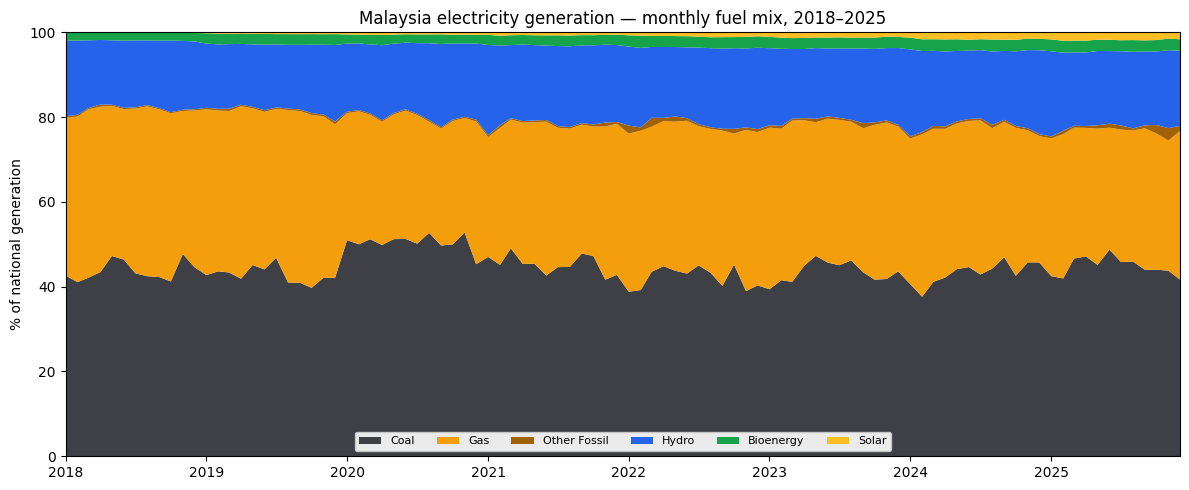

In [4]:
# Chart 1 — monthly fuel mix (% share), stacked
piv = gen.pivot(index="date", columns="fuel_name", values="share_pct")[FUEL_ORDER]
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(piv.index, [piv[f] for f in FUEL_ORDER], labels=FUEL_ORDER,
             colors=[FUEL_COLOR[f] for f in FUEL_ORDER])
ax.set_ylim(0, 100); ax.set_ylabel("% of national generation")
ax.set_title("Malaysia electricity generation — monthly fuel mix, 2018–2025")
ax.legend(loc="lower center", ncol=6, fontsize=8, framealpha=0.9)
ax.margins(x=0); fig.tight_layout()
fig.savefig(os.path.join(OUT, "fuel_mix.png"), dpi=130); plt.show()

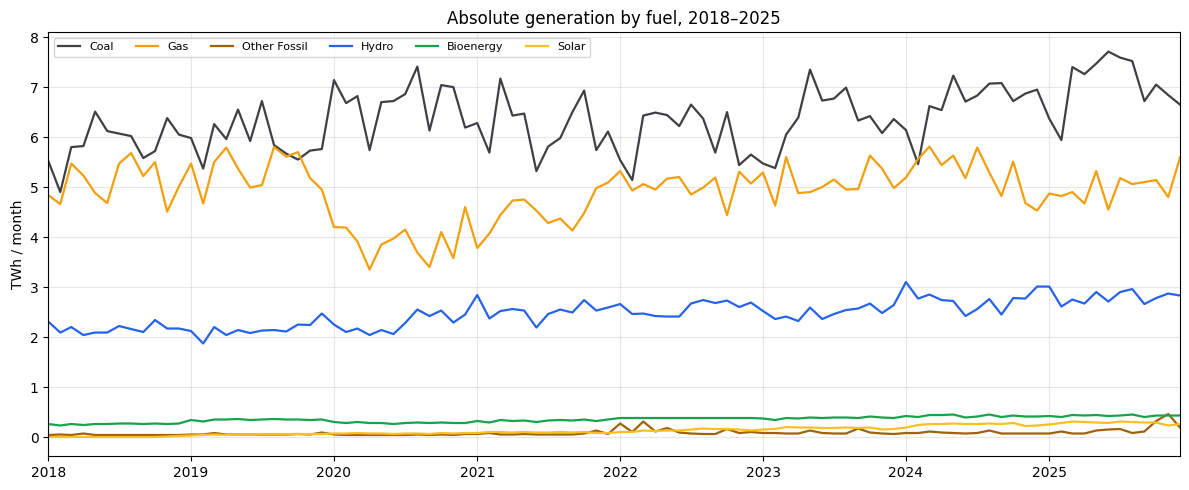

In [5]:
# Chart 2 — absolute generation by fuel (the point: coal's tonnage is rising even where its share isn't)
pivt = gen.pivot(index="date", columns="fuel_name", values="twh")[FUEL_ORDER]
fig, ax = plt.subplots(figsize=(12, 5))
for f in FUEL_ORDER:
    ax.plot(pivt.index, pivt[f], label=f, color=FUEL_COLOR[f], lw=1.6)
ax.set_ylabel("TWh / month"); ax.set_title("Absolute generation by fuel, 2018–2025")
ax.legend(ncol=6, fontsize=8); ax.grid(alpha=0.3); ax.margins(x=0); fig.tight_layout()
fig.savefig(os.path.join(OUT, "generation_by_fuel.png"), dpi=130); plt.show()

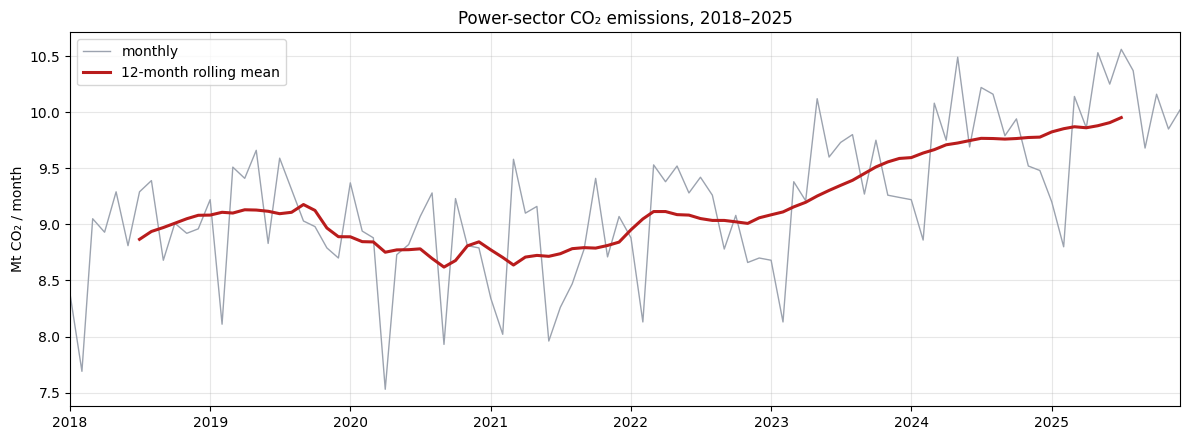

In [6]:
# Chart 3 — monthly national CO2 + 12-month rolling mean
s = summ.set_index("date").sort_index()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index, s.total_emissions_mtco2, color="#9ca3af", lw=1, label="monthly")
ax.plot(s.index, s.total_emissions_mtco2.rolling(12, center=True).mean(), color="#b91c1c", lw=2.2,
        label="12-month rolling mean")
ax.set_ylabel("Mt CO₂ / month"); ax.set_title("Power-sector CO₂ emissions, 2018–2025")
ax.legend(); ax.grid(alpha=0.3); ax.margins(x=0); fig.tight_layout()
fig.savefig(os.path.join(OUT, "emissions_monthly.png"), dpi=130); plt.show()

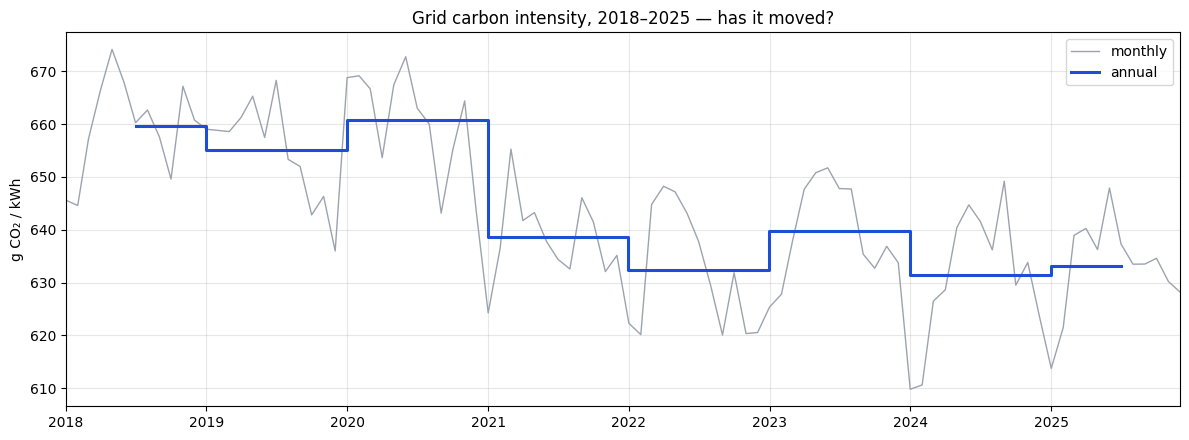

In [7]:
# Chart 4 — grid carbon intensity (g CO2 / kWh), monthly + annual
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index, s.co2_intensity_g_per_kwh, color="#9ca3af", lw=1, label="monthly")
ai = tot.set_index("year")["intensity_g_kwh"]
ax.step([pd.Timestamp(f"{y}-07-01") for y in ai.index], ai.values, where="mid",
        color="#1d4ed8", lw=2.2, label="annual")
ax.set_ylabel("g CO₂ / kWh"); ax.set_title("Grid carbon intensity, 2018–2025 — has it moved?")
ax.legend(); ax.grid(alpha=0.3); ax.margins(x=0); fig.tight_layout()
fig.savefig(os.path.join(OUT, "co2_intensity.png"), dpi=130); plt.show()

In [8]:
# Headline numbers (2018 baseline vs 2024 and 2025)
def pct(a, b): return 100 * (b / a - 1)
g0, g4, g5 = tot.loc[tot.year == 2018, "gen_twh"].iloc[0], tot.loc[tot.year == 2024, "gen_twh"].iloc[0], tot.loc[tot.year == 2025, "gen_twh"].iloc[0]
e0, e4, e5 = tot.loc[tot.year == 2018, "emis_mtco2"].iloc[0], tot.loc[tot.year == 2024, "emis_mtco2"].iloc[0], tot.loc[tot.year == 2025, "emis_mtco2"].iloc[0]
i0, i4, i5 = tot.loc[tot.year == 2018, "intensity_g_kwh"].iloc[0], tot.loc[tot.year == 2024, "intensity_g_kwh"].iloc[0], tot.loc[tot.year == 2025, "intensity_g_kwh"].iloc[0]
mix = ann.pivot(index="year", columns="fuel_name", values="share_pct")
gw = ann.pivot(index="year", columns="fuel_name", values="twh")
print(f"Generation 2018->2024: {g0:.1f} -> {g4:.1f} TWh  ({pct(g0,g4):+.1f}%);  ->2025: {g5:.1f} TWh ({pct(g0,g5):+.1f}%)")
print(f"CO2        2018->2024: {e0:.1f} -> {e4:.1f} Mt   ({pct(e0,e4):+.1f}%);  ->2025: {e5:.1f} Mt  ({pct(e0,e5):+.1f}%)")
print(f"Intensity  2018->2024: {i0:.0f} -> {i4:.0f} g/kWh ({pct(i0,i4):+.1f}%);  ->2025: {i5:.0f} ({pct(i0,i5):+.1f}%)")
print(f"Cumulative power-sector CO2, 2018-2025: {tot.emis_mtco2.sum():.0f} Mt")
print()
for f in ["Coal", "Gas", "Hydro", "Solar"]:
    print(f"{f:6s} share 2018/2024/2025: {mix.loc[2018,f]:.1f}% / {mix.loc[2024,f]:.1f}% / {mix.loc[2025,f]:.1f}%   "
          f"| TWh: {gw.loc[2018,f]:.1f} / {gw.loc[2024,f]:.1f} / {gw.loc[2025,f]:.1f}  ({pct(gw.loc[2018,f],gw.loc[2025,f]):+.0f}% 2018->2025)")
ren18 = mix.loc[2018, ["Hydro", "Solar", "Bioenergy"]].sum()
ren25 = mix.loc[2025, ["Hydro", "Solar", "Bioenergy"]].sum()
print(f"\nRenewables (hydro+solar+bioenergy) share 2018 -> 2025: {ren18:.1f}% -> {ren25:.1f}%  (+{ren25-ren18:.1f} pp)")

Generation 2018->2024: 161.3 -> 185.6 TWh  (+15.1%);  ->2025: 188.6 TWh (+16.9%)
CO2        2018->2024: 106.4 -> 117.2 Mt   (+10.2%);  ->2025: 119.4 Mt  (+12.2%)
Intensity  2018->2024: 660 -> 631 g/kWh (-4.3%);  ->2025: 633 (-4.0%)
Cumulative power-sector CO2, 2018-2025: 883 Mt

Coal   share 2018/2024/2025: 43.7% / 43.2% / 44.8%   | TWh: 70.5 / 80.2 / 84.5  (+20% 2018->2025)
Gas    share 2018/2024/2025: 37.9% / 34.2% / 31.8%   | TWh: 61.1 / 63.4 / 60.0  (-2% 2018->2025)
Hydro  share 2018/2024/2025: 16.1% / 17.7% / 17.8%   | TWh: 26.0 / 32.9 / 33.6  (+30% 2018->2025)
Solar  share 2018/2024/2025: 0.0% / 1.6% / 1.8%   | TWh: 0.0 / 3.0 / 3.4  (+11200% 2018->2025)

Renewables (hydro+solar+bioenergy) share 2018 -> 2025: 18.1% -> 22.4%  (+4.3 pp)


## A note on 2020

The 2020 spike in coal's share (≈50%, vs ≈43–44% in the surrounding years) is the COVID
lockdown: when demand collapsed, gas — the swing fuel on this grid — got dispatched down
hardest, so coal's *share* rose even as total generation fell. It's a real feature of the
data, not noise, and it's the reason the forecast notebook uses 2020 as its
structural-break stress test.